In [2]:
import matplotlib.pyplot as plt
import numpy as np
from fem_utils import * #con l'asterisco sto importando tutte le funzioni definite nel pacchetto fem_utils

In [3]:
#in questo lab affontiamo problemi che richiedono discretizzazione sia in spazio sia in tempo. Le condizioni al bordo
#possono dipendere dal tempo, e c'è una condizione iniziale che deve essere soddisfatta. Equazione del calore.
#nel teta-metodo, se teta=0 -> eulero esplicito; teta=0.5 -> Crank-Nicolson; teta=1 -> eulero implicito

# **Metodo degli Elementi Finiti per problemi parabolici**

Consideriamo il seguente problema tempo-dipendente nel caso monodimensionale, sul dominio $\Omega_T=\Omega\times[0,T)$, con $\Omega=(a,b)$:

Dati $\alpha:[0,T)\longrightarrow\mathbb{R}$, $\beta:[0,T)\longrightarrow\mathbb{R}$ e $u_0:\Omega\longrightarrow\mathbb{R}$, trovare $u:\Omega_T\longrightarrow\mathbb{R}$ tale che:

$$\begin{cases}
			\partial_t u - \partial_x(\gamma\partial_x u) = f, & \text{in}\ \Omega_T, \\
			u(a,t) = \alpha(t), & \text{per}\ t\in[0,T), \\
			u(b,t) = \beta(t), & \text{per}\ t\in[0,T), \\
			u(x,t=0) = u_0, & \text{in}\ \Omega\times\{0\}.
\end{cases}$$

Date condizioni al bordo di Dirichlet omogenee, la forma debole di questo problema è:

Trovare, $\forall t \in [0,T), \ u(t)\in V= H_0^1(\Omega)$ tale che

$$m(\partial_t u,v) + a(u,v) = F(v), \qquad \forall v\in V,$$

dove abbiamo definito:
$$m(u,v) = \int_a^b u v dx, \quad a(u,v) =\int_a^b \gamma \partial_x u \partial_x v dx, \quad F(v)=\int_a^b f v dx.$$

Fissato $t\in(0,T)$, la semi-discretizzazione in spazio si ottiene applicando il **Metodo degli Elementi Finiti**, scegliendo un sottospazio $V_h\subset V$ di dimensione $N_h$ finita e una sua base di funzioni linearmente indipendenti $\{\phi_j\}_{j=1}^{N_h}$. Il problema semi-discreto può quindi essere scritto in forma matriciale come segue:

Trovare, $\forall t\in [0,T), \ \mathbf{u}(t)\in\mathbb{R}^{N_h}$ tale che

$$
\mathbf{M}d_t\mathbf{u}(t)+\mathbf{A}\mathbf{u}(t) = \mathbf{f}(t),$$

dove
* $\mathbf{M}\in\mathbb{R}^{N_h\times N_h}:\ m_{ij}=m(\phi_j,\phi_i)$ è la matrice di massa degli Elementi Finiti;
* $\mathbf{A}\in\mathbb{R}^{N_h\times N_h}:\ a_{ij}=a(\phi_j,\phi_i)$ è la matrice di rigidezza;
* $\mathbf{f}(t)\in\mathbb{R}^{N_h}:\ \mathbf{F}(\phi_i)=[\mathbf{M}[f_{1}(t),\dots,f_{N_{h}}(t)]^{T}]_{i}$ è il vettore termine noto;
* $\mathbf{u}(t)\in\mathbb{R}^{N_h}:\ \mathbf{u}(t)=[u_1(t),\dots,u_{N_h}(t)]^T$.

Per il calcolo di $\mathbf{A}$ e $\mathbf{M}$ utilizziamo lo spazio degli Elementi Finiti

$$X_{h,0}^r = \{v_h\in\mathcal{C}([0,T]):\ v_h\big|_{[x_{i-1},x_i]}\in\mathbb{P}_r(x_{i-1},x_i)\}\cap\mathcal{C}([0,L]).$$

Il problema in tempo è quindi una ODE e può essere riscritto come segue:

$$
\begin{cases}
	d_t\mathbf{u}(t) =\tilde{\mathbf{f}}(t,\mathbf{u}(t))), & t\in[0,T), \\
	\mathbf{u}(0) =\mathbf{u}_0,
\end{cases}
$$

con termine noto $\tilde{\mathbf{f}}(t,\mathbf{u}(t))=-\mathbf{M}^{-1}\mathbf{A}\mathbf{u}(t)+\mathbf{M}^{-1}\mathbf{f}(t)$.

Dividiamo quindi $[0,T]$ in $N_t$ sottointervalli $(t_n, t_{n+1})$ tali che $t_0=0$, $t_{N_h}=T$, $t_n=n\Delta t$, con passo temporale $\Delta t=T/N_t$ e definiamo $\mathbf{u}^n=\mathbf{u}(t_n), \ n=0,\dots,N_t$.

Discretizziamo la derivata in tempo come:
$$		d_t \mathbf{u} \simeq \frac{\mathbf{u}^{n+1}-\mathbf{u}^n}{\Delta t}$$
e applichiamo il *$\theta$-metodo* per discretizzare la ODE:

$$		\frac{\mathbf{u}^{n+1}-\mathbf{u}^n}{\Delta t} = \theta\tilde{\mathbf{f}}^{n+1} + (1-\theta)\tilde{\mathbf{f}}^n, \qquad \theta\in[0,1].
$$

Sostituendo qui l'espressione di $\tilde{\mathbf{f}}$ otteniamo:
$$		\mathbf{M}\frac{\mathbf{u}^{n+1}-\mathbf{u}^n}{\Delta t}+\theta \mathbf{A}\mathbf{u}^{n+1} +(1-\theta)\mathbf{A}\mathbf{u}^n = \theta\mathbf{f}^{n+1}+(1-\theta)\mathbf{f}^n, \qquad \theta\in[0,1]. $$

Infine, il problema discreto diventa:

$\forall n=1,\dots,N_t$ trovare $\mathbf{u}^n\in\mathbb{R}^{N_h}$ tale che

$$
\begin{cases}
		\left(\frac{\mathbf{M}}{\Delta t} +\theta \mathbf{A}\right)\mathbf{u}^{n+1} = \left(\frac{\mathbf{M}}{\Delta t} - (1-\theta) \mathbf{A}\right)\mathbf{u}^{n} + \theta\mathbf{f}^{n+1}+(1-\theta)\mathbf{f}^n, & \forall n=1,\dots,N_t, \\
			\mathbf{u}^0 = \mathbf{u}_0.
\end{cases}
$$

A partire dall'istante $n=0$, possiamo ricavare iterativamente tutti i valori di $\mathbf{u}$ al passo successivo attraverso la risoluzione di un sistema lineare:

*Theta-metodo. Input: $\{\mathbf{f}^n\}_{n=1}^{N_t}$, $\mathbf{u}_0, \ \theta$. Output: $\mathbf{U}$*

1. Inizializzo $\mathbf{u}_{n}=\mathbf{u}_0$, $\mathbf{U}=[\mathbf{u}_n]$;
2.  For $n=1,\dots,N_t$

$\quad\quad$ 2.1. Calcolo $\mathbf{u}_{n+1}$ come soluzione del sistema lineare dato dal $theta$-metodo con parametro $\theta$;

$\quad\quad$ 2.2. Aggiorno $\mathbf{u}_{n}=\mathbf{u}_{n+1}$;

$\quad\quad$ 2.3. $\mathbf{U}=[\mathbf{U},\mathbf{u}_{n+1}]$.


Il $\theta$-metodo è incondizionatamente assolutamente stabile per $\theta\in[0.5,1]$ e condizionatamente assolutamente stabile per $\theta\in[0,0.5)$, con condizione di stabilità

$$		\Delta t\leq \frac{2}{\max|\lambda(\mathbf{M}^{-1}\mathbf{A})|}\approx ch^2,
$$

dove $\lambda(\mathbf{M}^{-1}\mathbf{A})$ indica gli autovalori della matrice $\mathbf{M}^{-1}\mathbf{A}$, da cui dipende la costante $c>0$.

# **Esercizio 1: equazione del calore**

Si consideri il seguente problema:

$$
\begin{cases}
  \partial_t u - \partial_{x} D \partial_x u = f(x), & \text{in}\ (0,L)\times [0,T), \\
  u(0,t)=u(L,t)=0, & \text{per}\ t\in [0,T), \\
  u(x,0)=u_0, & \text{in}\ (0,L),
\end{cases}
$$

con $D=1$, $L=1$, $T=1$,

$$ u_0(x)= \sin(\pi x), \qquad f(x,t)= (\pi^2-2)\sin(\pi x)e^{-2t}.$$

<mark>**Esercizio 1.1**<mark>

Si ricavi la formulazione debole e la formulazione algebrica dell'equazione, discretizzando in spazio usando il metodo FEM e in tempo il $\theta$-metodo.

**Soluzione**: si veda intro sopra. La ricavazione è identica qui.

In [4]:
#tipico esercizio di teoria in esame

<mark>**Esercizio 1.2**<mark>

Si implementi il $\theta$-metodo per la risoluzione del problema in tempo nella function `heat_solve`, definita come segue:

      heat_solve(grid, D, f, u0, T, dt, theta)
      ##
      ##
      return uh,th

dove in input abbiamo:

  * grid, griglia FEM 1D
  * $D$ il coefficiente di diffusione;
  * $f$ termine noto;
  * $u_0$ dato iniziale;
  * $T$ istante di tempo finale;
  * $dt$ passo temporale;
  * theta, parametro del theta-metodo;

ed in output

  * $uh$ matrice contentente i corrispondenti valori della soluzione $u_{i,n}=u_i(t^n)$, $i=1,\dots,N_h$, $n=1,\dots,N_T$;
  * $th$ vettore contenente gli istanti temporali: $t^n$, $n=0,\dots,N_t$.

In [5]:
def heat_solve(grid, D, f, u0, T, dt, theta):
  """"
  Input:
     grid    Grid object providing nodal coordinates in grid.nodes.
     D      (float)                  Coefficiente di diffusione (positivo).
     f      (lambda function)        Forzante. Si assume f = f(x,t).
     u0     (lambda function)        Condizione iniziale.
     T      (float)                  Tempo finale
     dt     (float)                  Passo temporale.
     theta  (float)                  Parametro del theta-metodo.

  Output:
    uh     (numpy.ndarray)-> matrix  Matrice contenente la soluzione approssimata del problema. 
                                      Uij approssima uh(dof_i, t_j): ogni colonna è un tempo fissato.
    th      (numpy.ndarray)-> vector Griglia temporale.
  """""
  # estrazione informazione dalla griglia/mesh (estraggo solo gli attributi h, nodes, N in quanto è come se la grid,
  #in input alla funzione heat fosse già stata costruita)
  h = grid.h
  nodes = grid.nodes
  Nele = grid.N

  # Griglia temporale  
  Nt = int((T-0)/dt) #Nt intervalli di tempo -> Nt+1 nodi
  th = np.linspace(0, T, Nt+1)

  # Inizializzo la soluzione (è una matrice con nodi spaziali nelle righe e nodi temporali in colonne)
  uh = np.zeros((len(nodes), len(th)))

  # condizione iniziale
  u0h=fun2dof(grid, u0) #proietta una funzione generica in un sottospazio  
  #oppure: u0h = u0(nodes)
  uh[:, 0] = u0h 

  # Boundary conditions (Dirichlet) -> se dipendessero dal tempo, dovrei metterle nel ciclo for, in quanto dovrebbero
  #essere modificate e aggiornate a ogni ciclo in tempo (qui sono omogenee quindi posso crearle fuori dal ciclo for)
  dirichlet_nodes = [0, -1]  
  dirichlet_values = [0, 0] 

  # Costruzione del vettore dei valori al bordo
  bc_values = np.zeros(Nele + 1)
  bc_values[dirichlet_nodes] = dirichlet_values

  # Matrice di restrizione R
  keep_dof = np.ones(Nele + 1, dtype=bool)
  keep_dof[dirichlet_nodes] = False
  R = create_restriction(keep_dof)

  # Costruzione matrici di massa e diffusione (non dipendono dal tempo quindi posso crearle fuori)
  A=diffusion(grid)
  A=D*A #D è il coefficiente di diffusione
  M=mass(grid)

  # Costruzioni matrici per il theta metodo (G non dipende dal tempo; G_0 non dipende dal tempo, per cui il termine noto
  #all'istante iniziale posso costruirlo fuori dal ciclo mediante matrice di restrizione-> i termini successivi invece nel ciclo)
  G=M/dt+theta*A
  G_0=R @ G @ R.T

  
  # Ciclo temporale (all'istante 0 sto calcolando la soluzione all'istante1, ... all'istante th-1 sto calcolando la soluzione a th, ultimo
  #istante temporale, per cui faccio range da 0 a th-1)
  for n in range(len(th)-1): #oppure range(Nt) poiché l'intervallo temporale ha Nt+1 nodi, e il nodo allo 0 lo abbiamo già
    
    # tempo dt e dt+1
    t_old=th[n] #t^n
    t_new=th[n+1] #t^n+1
    # termini noti al tempo dt e dt+1
    f_old=f(nodes, t_old) #si tratta della f all'istante t^n
    f_new=f(nodes, t_new) #si tratta della f all'istante t^n+1

    # termine noto
    F_old=M @ f_old
    F_new=M @ f_new

    ### Theta metodo ##
    g = (M/dt - (1-theta)*A) @ uh[:, n] + theta*F_old + (1-theta)*F_new #uh[ :, n] è uh in tutti i nodi all'istante t^n
    g_0 = R @ (g - G @ bc_values) #nodi interni

    u_new_0 = np.linalg.solve(G_0, g_0) #si tratta la soluzione all'istante t^n+1 ai nodi interni

    # Ricostruzione della soluzione completa (che è quella ai nodi interni combinata a quanto si ha agli estremi)
    uh[:, n+1] = R.T @ u_new_0 + bc_values

  return uh, th

<mark>**Esercizio 1.3**<mark><br>

Risolvere il problema con i seguenti dati: $h=0.1$, $\Delta t = 0.01$ e $\theta = 0.5$.

In [6]:
# Dominio
a, b = 0, 1
h = 0.1

# generazione griglia
Nele=int((b-a)/h)
grid=Grid(a, b, Nele)
grid.compute_geometry()

# Dati del tempo
T = 1
dt = 0.01
# Coefficiente di diffusione
D = 1
# Parametro per il theta methodo
theta = 0.5
# Termine noto
f = lambda x, t: (np.pi*np.pi -2)*np.sin(np.pi*x)*np.exp(-2*t)
# Condizione iniziale
u0 = lambda x: np.sin(np.pi*x)

# Risoluzione equazione del calore
uh, th=heat_solve(grid, D, f, u0, T, dt, theta)

<mark>**Esercizio 1.4**<mark><br>

Data la soluzione esatta
</br></br>
$$
u_{\text{ex}}(x,t)=\sin(\pi x)e^{-2t}
$$
</br>

rappresentare su due grafici la soluzione esatta e la soluzione approssimata in $[0,T)$. Si sfrutti la funzione *xtplot*.

In [7]:
from fem_utils_plot import xtplot 
help(xtplot) 

Help on function xtplot in module fem_utils_plot:

xtplot(grid, u, t, plot_type='fade', color='b', linestyle='-', name_gif='solution_animation')
    Plot FEM solution in different formats.

    Args:
        grid (Grid): Finite element grid.
        u (np.ndarray): Solution matrix (space × time).
        t (np.ndarray): Time vector.
        plot_type (str): Plot type: "animation", "surface", "fade".
        color (str): Plot color.
        linestyle (str): Line style.
        name_gif (str): GIF filename base.

    Returns:
        None



In [8]:
#a noi interessano come argomenti solo grid, u, t, plot_type

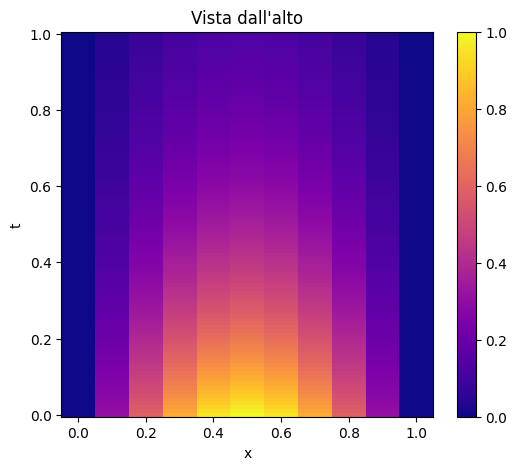

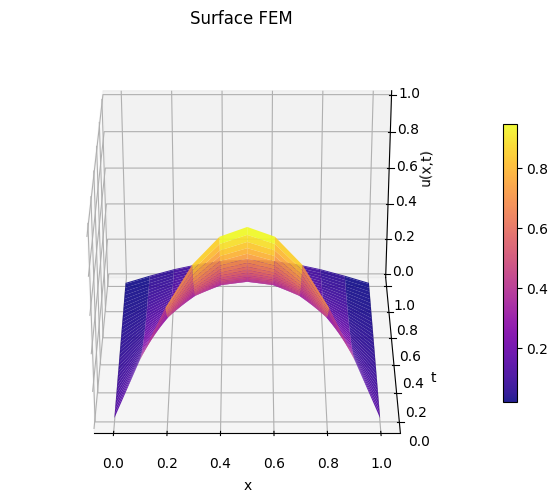

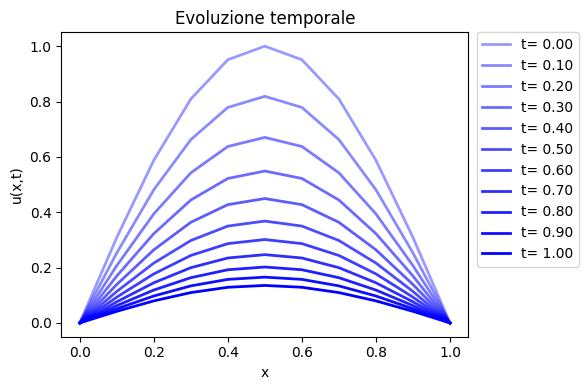

In [9]:
uex = lambda x,t: np.sin(np.pi*x)*np.exp(-2*t)

# Queste linee di codice servono per proiettare la soluzione esatta sullo spazio Vh (sui nodi della griglia) e averla in un formato compatibile 
# con quello richiesto da xtplot.
uex_t = np.zeros(uh.shape)  # Inizializzazione uex_t

# Soluzione approssimata
xtplot(grid, uh, th,'surface',color='b') #oppure 'fade' oppure 'surface'
plt.show()

# soluzione esatta
for i in range(len(th)):
  uext = lambda x: uex(x, th[i])
  uex_t[:,i] = fun2dof(grid, uext) #ho trasformato la soluzione esatta da lambda function a proiezione sulla griglia spazio-temporale della
  #soluzione numerica creata prima con heat_solve

xtplot(grid, uex_t, th,'fade')
plt.show()

In [10]:
#con l'evoluzione del tempo la soluzione di appiattisce, ed è l'effetto della diffusione -> si attenua la soluzione, profilo
#parabolico che tende a schiacciarsi sempre di più. Le condizioni di Dirichlet fissano il valore della soluzione agli estremi.

<mark>**Esercizio 1.5**<mark><br>

Calcolare l'errore
</br></br>
$$
e(h,\Delta t):=\max_{t^{n}}\sqrt{\int_{0}^{L}|u_{ex}(x,t^{n})-u_{h}(x,t^{n})|^{2}dx}
$$
</br>

cioè il massimo, in tempo, degli errori in norma $L^2$, dove $u_{h}(x,t^{n}):=\sum_{i=1}^{N_{h}}u_{i,n}\phi_{i}(x)$.

In [11]:
# generazione griglia
Nele = int((b - a) / h)
grid = Grid(a, b, Nele)
grid.compute_geometry()

#inizializzo l'errore come lista vuota

err_t = [] 

# calcolo dell'errore
for i in range(len(th)):
  uex_t = lambda x: uex(x, th[i]) #soluzione esatta in tutti i nodi spaziali all'istante t^i
  uh_t = lambda x: np.interp(x, grid.nodes, uh [:, i])
  err_t.append(error_l2(grid, uex_t, uh_t))

err = max(err_t)

print(err)

0.008665354108310994


<mark>**Esercizio 1.6**<mark><br>

Risolvere il problema con $h=0.01$ e $\theta=1$ per $\Delta t$ che assume i valori $\{0.2,\ 0.1,\ 0.05,\ 0.025\}$ e rappresentare su un grafico l'andamento dell'errore $e(h,\Delta t)$ al variare di $\Delta t$. Cosa si osserva?

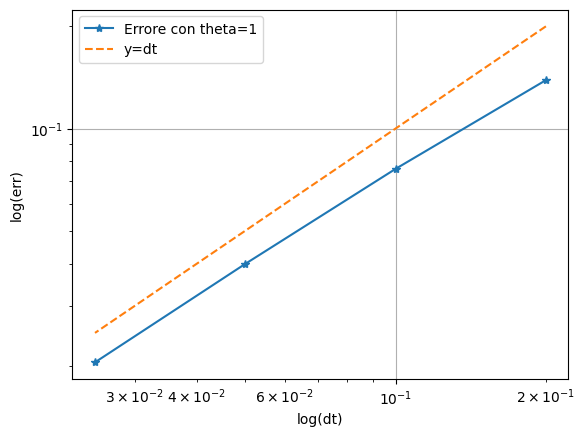

In [12]:
theta=1
#generazione della griglia
h=0.01
Nele=int((b-a)/h)
grid=Grid(a, b, Nele)
grid.compute_geometry()

t_list=[0.2, 0.1, 0.05, 0.025]

errors=[]

for dt in t_list:
    #risoluzione dell'equazione del calore
    uh, th=heat_solve(grid, D, f, u0, T, dt, theta)

    #calcolo dell'errore
    err_t=[]
    for i in range(len(th)):
        uex_t=lambda x: uex(x, th[i])
        uh_t=lambda x: np.interp(x, grid.nodes, uh[:, i])
        err_t.append(error_l2(grid, uex_t, uh_t))

    errors.append(max(err_t))


plt.figure()
plt.loglog(t_list, errors, '*-')
plt.loglog(t_list, t_list, '--')
plt.grid()
plt.xlabel('log(dt)')
plt.ylabel('log(err)')
plt.legend(['Errore con theta=1','y=dt'])
plt.show()

In [13]:
#emerge che l'errore converge con ordine 1 (theta=1 -> eulero implicito -> corretto che si abbia una convergenzza lineare)

<mark>**Esercizio 1.7**<mark><br>

Risolvere nuovamente il problema con $h=0.01$ e $\theta=0$ per $\Delta t$ che assume i valori $\{0.2,\ 0.1,\ 0.05,\ 0.025\}$. Rappresentare su un grafico l'andamento dell'errore $e(h,\Delta t)$ al variare di $\Delta t$. Cosa si osserva?

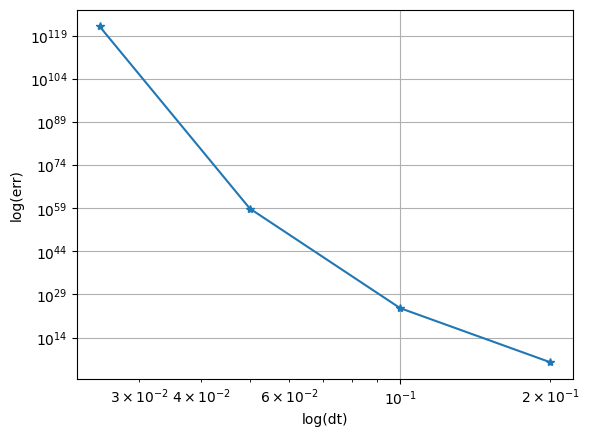

In [14]:
theta=0
#generazione della griglia
h=0.01
Nele=int((b-a)/h)
grid=Grid(a, b, Nele)
grid.compute_geometry()

t_list=[0.2, 0.1, 0.05, 0.025]

errors=[]

for dt in t_list:
    #risoluzione dell'equazione del calore
    uh, th=heat_solve(grid, D, f, u0, T, dt, theta)

    #calcolo dell'errore
    err_t=[]
    for i in range(len(th)):
        uex_t=lambda x: uex(x, th[i])
        uh_t=lambda x: np.interp(x, grid.nodes, uh[:, i])
        err_t.append(error_l2(grid, uex_t, uh_t))

    errors.append(max(err_t))


plt.figure()
plt.loglog(t_list, errors, '*-')
plt.grid()
plt.xlabel('log(dt)')
plt.ylabel('log(err)')
plt.show()

In [15]:
#emerge che l'errore esplode al decrescere del passo temporale -> eulero esplicito è condizionatamente assolutamente stabile -> 
#risulta chiaro che h e dt NON soddisfano la condizione sulla a-stabilità di eupero esplicito

# Esercizi per casa

## **Esercizio 2: problema diffusione-trasporto tempo dipendente**

Si consideri il problema di diffusione-trasporto tempo dipendente

$$
\begin{cases}
    \partial_t u = \alpha \partial_{xx} u - \beta \partial_x u + f(x), & \text{in}\ (0,L)\times [0,T), \\
    u(0,t)=0,\ u(L,t)=0, & \text{per}\ t\in [0,T), \\
    u(x,0)=u_0, & \text{in}\ (0,L)
\end{cases}
$$

con coefficienti costanti, $\alpha=10^{-2}$, $\beta=1$, $L=1$, $T=0.25$, forzante nulla, $f(x,t) \equiv 0$, e profilo iniziale

$$
u_0(x)= \begin{cases}
\cos^{4}(4\pi x - 2\pi) & 0.375\le x \le 0.625\\
0 & \text{altrimenti}.
\end{cases}
$$

<mark>**Esercizio 2.1**<mark>

Si ricavi la formulazione debole e la formulazione algebrica dell'equazione, discretizzata in spazio con il metodo FEM e in tempo con il $\theta$-metodo.

In [16]:
#vedi soluzione pdf (sarebbe domanda di teoria)

<mark>**Esercizio 2.2**<mark>

Si implementi la function `parabolic_solve`, che risolva il problema di diffusione-trasporto tempo dipendente, definita come segue:

    parabolic_solve(grid, \alpha, \beta, f, u0, T, dt, theta)
    ##
    ##
    return uh,th

dove in input abbiamo:

  * grid, griglia FEM 1D
  * $\alpha$, $\beta$ coefficiente di diffusione e trasporto, rispettivamente;
  * $f$ termine noto;
  * $u_0$ dato iniziale;
  * $T$ istante di tempo finale;
  * $dt$ passo temporale;
  * theta, parametro del theta-metodo;

ed in output

  * $uh$ matrice contentente i corrispondenti valori della soluzione $u_{i,n}=u_i(t^n)$, $i=1,\dots,N_h$, $n=1,\dots,N_T$;
  * $th$ vettore contenente gli istanti temporali: $t^n$, $n=0,\dots,N_t$.

In [26]:
def parabolic_solve(grid, alpha,beta,f, u0,T,dt,theta):
  """"
  Input:surface
     grid    Grid object providing nodal coordinates in grid.nodes.
     alpha   (float)                 Coefficiente di diffusione (positivo).
     beta   (float)                  Velocità di trasporto.
     f      (lambda function)        Forzante. Si assume f = f(x,t).
     u0     (lambda function)        Condizione iniziale.
     T      (float)                  Tempo finale.
     dt     (float)                  Passo temporale.
     theta  (float)                  Parametro del theta-metodo.

  Output:
    uh     (numpy.ndarray)-> matrix  Matrice contenente la soluzione
                                    approssimata del problema. Uij
                                    approssima u(dof_i, tj): ogni colonna è un
                                    tempo fissato.
    th      (numpy.ndarray)-> vector Griglia temporale.
  """""
  #estrazione informazione dalla mesh
  h=grid.h
  nodes=grid.nodes
  Nele=grid.N

  #griglia temporale
  Nt=int((T-0)/dt)
  th=np.linspace(0, T, Nt+1)

  #inizializzo la soluzione
  uh=np.zeros((len(nodes), len(th)))

  #condizione iniziale
  u0h=fun2dof(grid, u0)
  uh[:, 0]=u0h

  #boundary conditions (Dirichlet)
  dirichlet_nodes=[0, -1] #oppure [0, Nele]
  dirichlet_values=[0.0, 0.0]

  #costruzione del vettore dei valori al bordo
  bc_values=np.zeros(Nele+1)
  bc_values[dirichlet_nodes]=dirichlet_values

  #matrice di restrizione R
  keep_dof=np.ones(Nele+1, dtype=bool)
  keep_dof[dirichlet_nodes]=False
  R=create_restriction(keep_dof)

  #costruzione matrici di massa, diffusione e trasporto
  M=mass(grid)
  A_diff=diffusion(grid)
  A_trasp=transport(grid)

  A=alpha*A_diff+beta*A_trasp

  #costruzioni matrici per il theta metodo, dal momento che non dipendono
  #dall'istante temporale -> le metteremo fuori dal ciclo temporale
  G=M/dt + theta*A
  G_0=R @ G @ R.T

  #ciclo temporale
  for n in range(len(th)-1):
    #tempo dt e dt+1
    t_old=th[n]
    t_new=th[n+1]

    #termini noti al tempo dt e dt+1
    f_old=lambda x: f(x, t_old)
    f_new=lambda x: f(x, t_new)

    #dofs
    f_old_dofs=fun2dof(grid, f_old)
    f_new_dofs=fun2dof(grid, f_new)

    #funzionali lineari
    F_old=M @ f_old_dofs
    F_new=M @ f_new_dofs

    #theta metodo
    rhs=(M/dt-(1-theta)*A) @ uh[:, n] + theta*F_new+(1-theta)*F_old
    rhs_0=R @ (rhs-G @ bc_values)
    u_new_bc=np.linalg.solve(G_0, rhs_0)

    #ricostruzione della soluzione completa
    uh[:, n+1]=R.T @ u_new_bc + bc_values

  return uh, th

<mark>**Esercizio 2.3**<mark><br>

Si testi la funzione *parabolic_solve* con $h =0.005$, $\Delta t = 0.001$ per diverse scelte del parametro $\theta$. Commentare i risultati.

In [27]:
# Dati del problema
alpha, beta = 0.01, 1
L = 1 
a, b = 0, L

# Griglia FEM
h = 0.005
Nele = int((b - a) / h)
grid = Grid(a, b, Nele)
grid.compute_geometry()

# Tempo
T = 0.25
dt = 0.001

# Termine noto
f = lambda x,t : 0*x*t

# Dato iniziale
u0 = lambda x : np.cos(4*np.pi*x - 2*np.pi)**4 * (x <= 0.625) * (x >= 0.375)

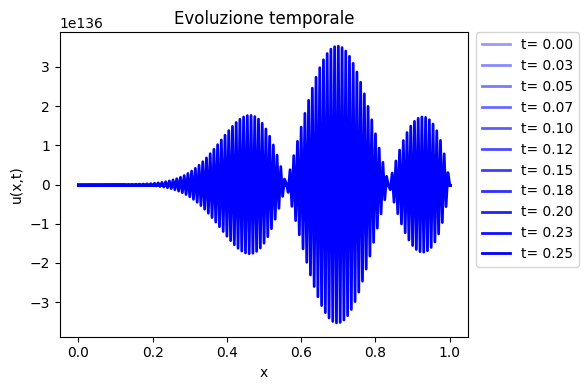

In [28]:
#theta=0
#risoluzione problema parabolico

uh, th=parabolic_solve(grid, alpha, beta, f, u0, T, dt, 0.0)
#grafico
xtplot(grid, uh, th, 'fade')
plt.show()

In [ ]:
#la soluzione discreta esplode in quanto eulero esplicito (corrispondente alla
#scelta theta=0) è condizionatamente assolutamente stabile e con questa zombinazione di h e dt
#ci troviamo fuori dalla regione di a-stabilità. Notare l'ordine di grandezza dell'asse y.

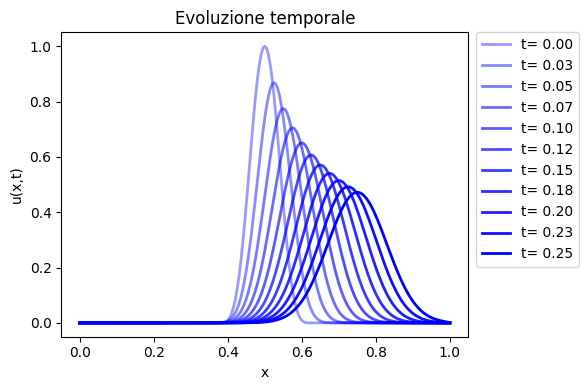

In [29]:
#theta=0.5
#risoluzione problema parabolico

uh, th=parabolic_solve(grid, alpha, beta, f, u0, T, dt, 0.5)
#grafico
xtplot(grid, uh, th, 'fade')
plt.show()

In [ ]:
#in questo caso a soluzione discreta si comporta come dovrebbe, ossia si può notare
#che la soluzione discreta viene trasportata nella direzione positiva dell'asse x (coefficiente
#beta>0) ed è soggetta a difffusione. Ricordiamo che il metodo di Crank-Nicholson
#corrispondenta alla scelta theta=0.5 è incondizionatamente a-stabile.

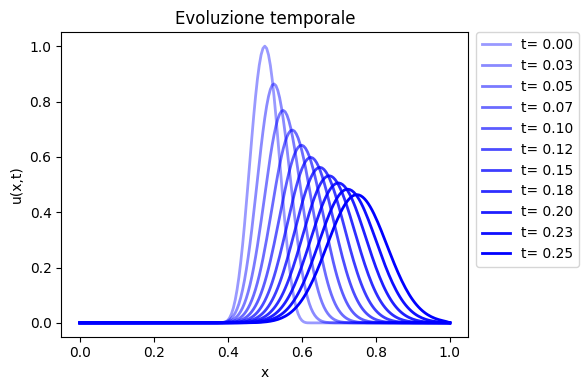

In [30]:
#theta=1
#risoluzione problema parabolico

uh, th=parabolic_solve(grid, alpha, beta, f, u0, T, dt, 1.0)
#grafico
xtplot(grid, uh, th, 'fade')
plt.show()

In [ ]:
#anche in questo caso, corrispondente a una discretizzazione col metodo di eulero implicito
#la soluzione è stabile e si comporta come ci si aspetta.

<mark>**Esercizio 2.4**<mark><rb>

Si ripeta il punto precedente variando i valori di $\alpha>0$ e $\beta\in\mathbb{R}$. Come cambia la soluzione numerica?

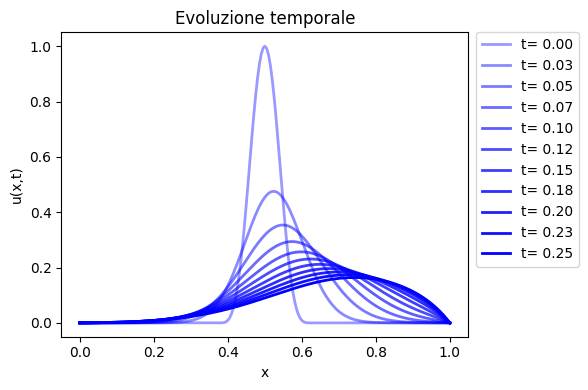

In [31]:
#esempio 1: aumento il coefficiente di diffuzione alpha
#eulero implicito con alpha=0., beta=1
#risoluzione problema parabolico

uh, th=parabolic_solve(grid, 1e-1, 1, f, u0, T, dt, 1.0)
#grafico
xtplot(grid, uh, th, 'fade')
plt.show()

In [ ]:
#aumentando il coefficiente di diffusione, la soluzione è soggetta maggiormente all'effetto 
#di diffuzione, e possiamo osservare la più rapida diminuzione dell'ampiezza della condizione iniziale.

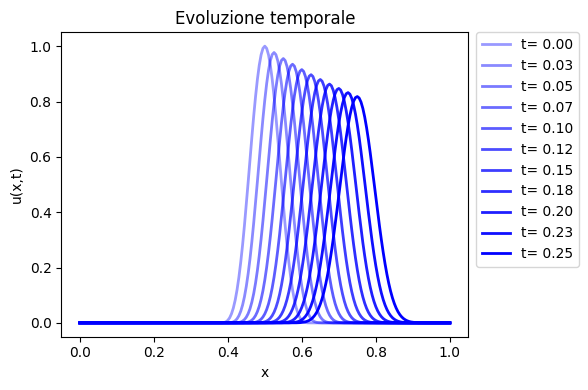

In [32]:
#esempio 2: diminuisco il coefficiente di diffusione
#eulero implicito con alpha=0.001, beta=1

#risoluzione problema parabolico

uh, th=parabolic_solve(grid, 1e-3, 1, f, u0, T, dt, 1.0)
#grafico
xtplot(grid, uh, th, 'fade')
plt.show() 

In [ ]:
#riducendo il coefficiente alpha, la soluzione è meno soggetta a diffuzione e si osserva la
#condizione iniziale trasportata lungo la direzione positiva dell'asse x con lieve diminuzione della sua ampiezza.

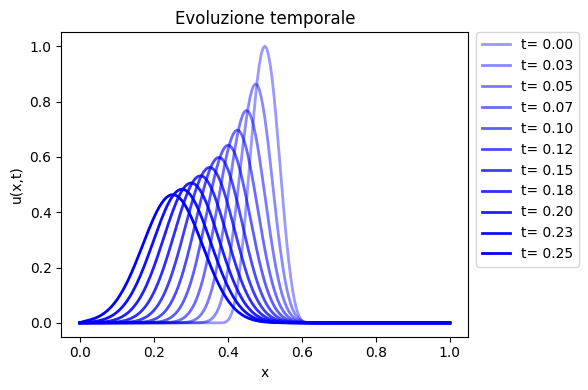

In [33]:
#esempio 3: inverto il verso di trasporto (beta<0)
#eulero implicito con alpha=0.01, beta=-1

#risoluzione problema parabolico

uh, th=parabolic_solve(grid, 1e-2, -1, f, u0, T, dt, 1.0)
#grafico
xtplot(grid, uh, th, 'fade')
plt.show()

In [ ]:
#invertendo il segno del coefficiente di trasporto, abbiamo invertito il verso della 
#velocità di trasporto. Adesso la condizione iniziale viene trasportata lungo la direzione negativa dell'asse x.

<mark>**Esercizio 2.5**<mark><rb>

Si ripetano i test svolti nell'esercizio 2.4, utilizzando il metodo di Crank-Nicolson e Eulero esplicito. Si commentino i risultati.

In [ ]:
#Si possono copiare i test dell’esercizio 2.4 cambiando 𝜃 = 0, 0.5. Con il metodo di
#Crank-Nicolson si osservano risultati uguali a quelli ottenuti con Eulero implicito. Con il metodo
#di Eulero esplicito, la soluzione esplode negli istanti finali e non possiamo osservare i cambiamenti
#attesi dovuti alla variazione dei parametri. Ci troviamo infatti al di fuori della regione di assoluta
#stabilità.